# 第066讲 核方法的选择与代价

这是可顺序重跑的完整实验。请在本讲目录打开Notebook。所有数据原创合成，输出写入outputs/notebook，保留冻结参考报告。先读问题与公式，再观察实际数值；不要根据测试结果追加候选后仍称其为封存评估。

In [1]:
# 环境与依赖版本。没有任何网络下载。
import json, sys, subprocess
from pathlib import Path
import numpy as np
import scipy, sklearn, pandas as pd
from IPython.display import display, Image
from common import load_data, safe_output, write_json
print({'python': sys.version.split()[0], 'numpy': np.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__})
data = load_data()
print({name: len(part['id']) for name, part in data.items()})

{'python': '3.12.14', 'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0'}
{'train': 240, 'validation': 120, 'test': 120}


## 1 不先看准确率 先算核值
RBF把平方距离变成相似度。这里两训练点距离恰为1，gamma取log2，所以非对角应为1/2。打印矩阵后用纸笔检查，不要仅相信函数名。

In [2]:
from kernels import rbf, polynomial, krr_fit, krr_predict
X = np.array([[-0.5], [0.5]])
y = np.array([1., -1.])
K = rbf(X, X, gamma=np.log(2))
print('K =', K)
print('Symmetric eigenvalues =', np.linalg.eigvalsh(K))
# 对角加0.5后求解，不显式形成逆矩阵。
model = krr_fit(X, y, alpha=0.5, gamma=np.log(2))
print('coefficients =', model['coefficient'])
print('predictions =', krr_predict(model, [[-0.5], [0.0], [0.5]]))

K = [[1.  0.5]
 [0.5 1. ]]
Symmetric eigenvalues = [0.5 1.5]
coefficients = [ 1. -1.]
predictions = [ 5.0000000e-01  1.5138842e-16 -5.0000000e-01]


## 2 真正执行冻结协议
每族9次验证拟合，选中后在训练加验证上重训一次。计时不用于选择，测试标签只用于最终评价。下面直接调用随包、可阅读的experiment.py，不读取冻结指标冒充新实验。

In [3]:
from experiment import run
report = run()
write_json(safe_output('outputs/notebook/result.json'), report)
rows = []
for family, row in report['models'].items():
    chosen = row['trials'][row['best_trial']]
    rows.append({'model': family, 'candidates': len(row['trials']), 'params': str(chosen['params']), 'validation': chosen['validation_accuracy'], 'test': row['test_accuracy'], 'support_vectors': row['support_vectors']})
display(pd.DataFrame(rows))

,model,candidates,params,validation,test,support_vectors
0,linear,9,{'C': 0.0001},0.533333,0.5,NaN
1,rbf,9,"{'C': 1.0, 'gamma': 0.1}",1.000000,1.0,100.0
2,poly,9,"{'C': 0.1, 'degree': 2, 'gamma': 0.5, 'coef0':...",1.000000,1.0,95.0


## 3 资源口径要分清
批延迟单位为毫秒，包括标准化管线。数组字节不等于峰值RAM，序列化大小也不是峰值RAM。15次测量的原始数值保存在report中；同样代码在共享机器上重跑会有时间抖动。

In [4]:
rows = []
for name, row in report['models'].items():
    t = row['batch_latency']
    rows.append({'model': name, 'batch_size': t['batch_size'], 'repeats': t['repeats'], 'median_ms': t['median_ms'], 'q25_ms': t['q25_ms'], 'q75_ms': t['q75_ms'], 'selected_array_bytes': row['selected_prediction_arrays_bytes'], 'serialized_bytes': row['serialized_pipeline_bytes']})
display(pd.DataFrame(rows))
print('Unscaled diagnostic accuracy:', report['unscaled_rbf']['test_accuracy'])

,model,batch_size,repeats,median_ms,q25_ms,q75_ms,selected_array_bytes,serialized_bytes
0,linear,120,15,0.093932,0.091894,0.100647,56,1015
1,rbf,120,15,0.424402,0.392965,0.472931,2840,5150
2,poly,120,15,0.235887,0.229903,0.329257,2700,4971


Unscaled diagnostic accuracy: 0.7666666666666667


## 4 近似核不是免费精确核
在训练输入上比较Gram矩阵相对Frobenius误差。下面的标准差是5个种子之间的样本标准差，不是泛化误差或置信区间。

In [5]:
display(pd.DataFrame([{k:v for k,v in row.items() if k != 'relative_frobenius_errors'} for row in report['approximation']]))
display(pd.DataFrame(report['storage']))

,method,components,mean_error,std_error,feature_matrix_bytes
0,Nystroem,8,0.449394,0.043024,10240
1,RFF,8,1.037819,0.061710,10240
2,Nystroem,16,0.219495,0.062236,20480
3,RFF,16,0.698406,0.066186,20480
4,Nystroem,32,0.064947,0.040678,40960
5,RFF,32,0.514158,0.091370,40960
6,Nystroem,64,0.003312,0.002232,81920
7,RFF,64,0.390778,0.037950,81920


,n,dense_float64_gram_bytes,feature64_float64_bytes
0,100,80000,51200
1,1000,8000000,512000
2,10000,800000000,5120000
3,100000,80000000000,51200000


## 显式验收
以下启动两个真正的新Python进程，分别运行普通与-O模式。任何失败都会让Notebook停止，代码没有用assert充当唯一验证。

In [6]:
for optimize in [False, True]:
    mode = ['-O'] if optimize else []
    destination = 'outputs/notebook/tests-O.json' if optimize else 'outputs/notebook/tests.json'
    proc = subprocess.run([sys.executable, *mode, 'test_experiment.py', '--report', 'outputs/notebook/result.json', '--out', destination], capture_output=True, text=True, check=True)
    print(proc.stdout.strip())

{"status": "passed", "checks": 175, "python_optimized": false}


{"status": "passed", "checks": 175, "python_optimized": true}


## 解释图
每张图重新从刚生成的report制作，并作为PNG嵌入Notebook。图的中文读法在讲义对应图注；英文坐标使图的重建不依赖中文绘图字体。

In [7]:
from plots import make
figure_paths = make(report, Path('outputs/notebook/figures'))
print('Generated figure count:', len(figure_paths))

Generated figure count: 6


### 图 1 01_kernel_shapes
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

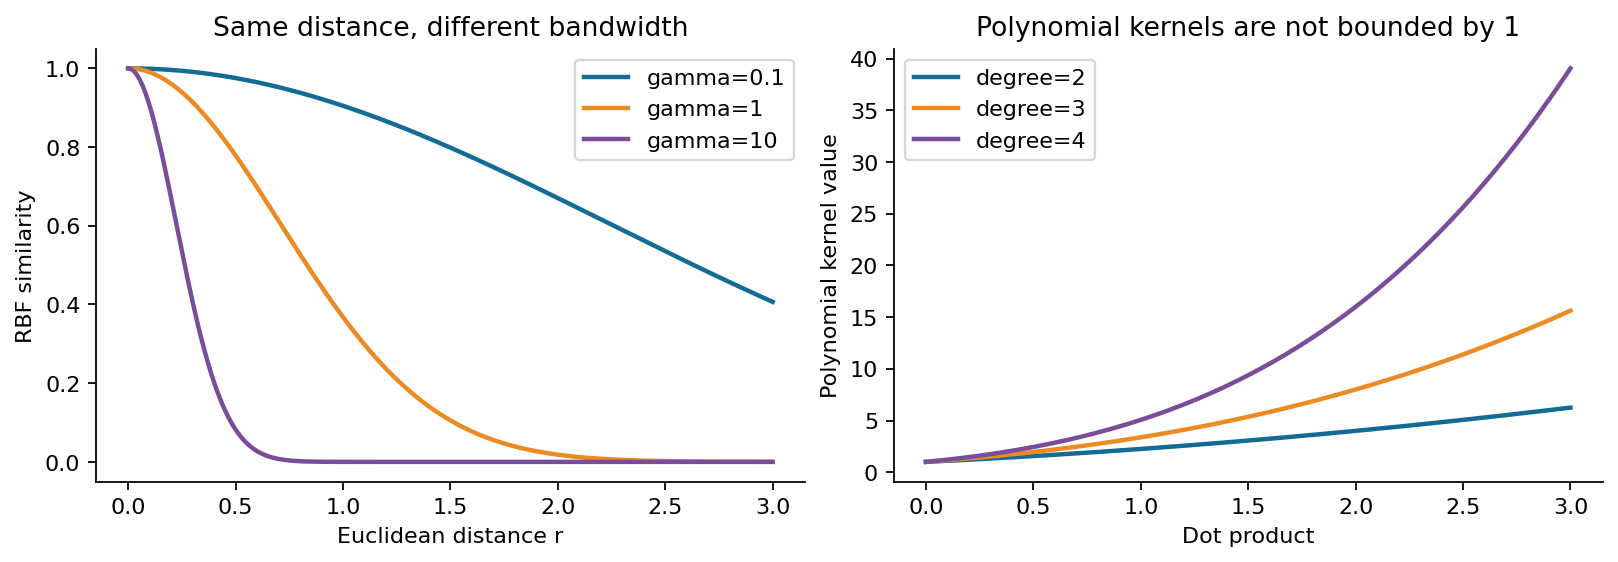

In [8]:
display(Image(filename=str(figure_paths[0])))

### 图 2 02_bandwidth_boundaries
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

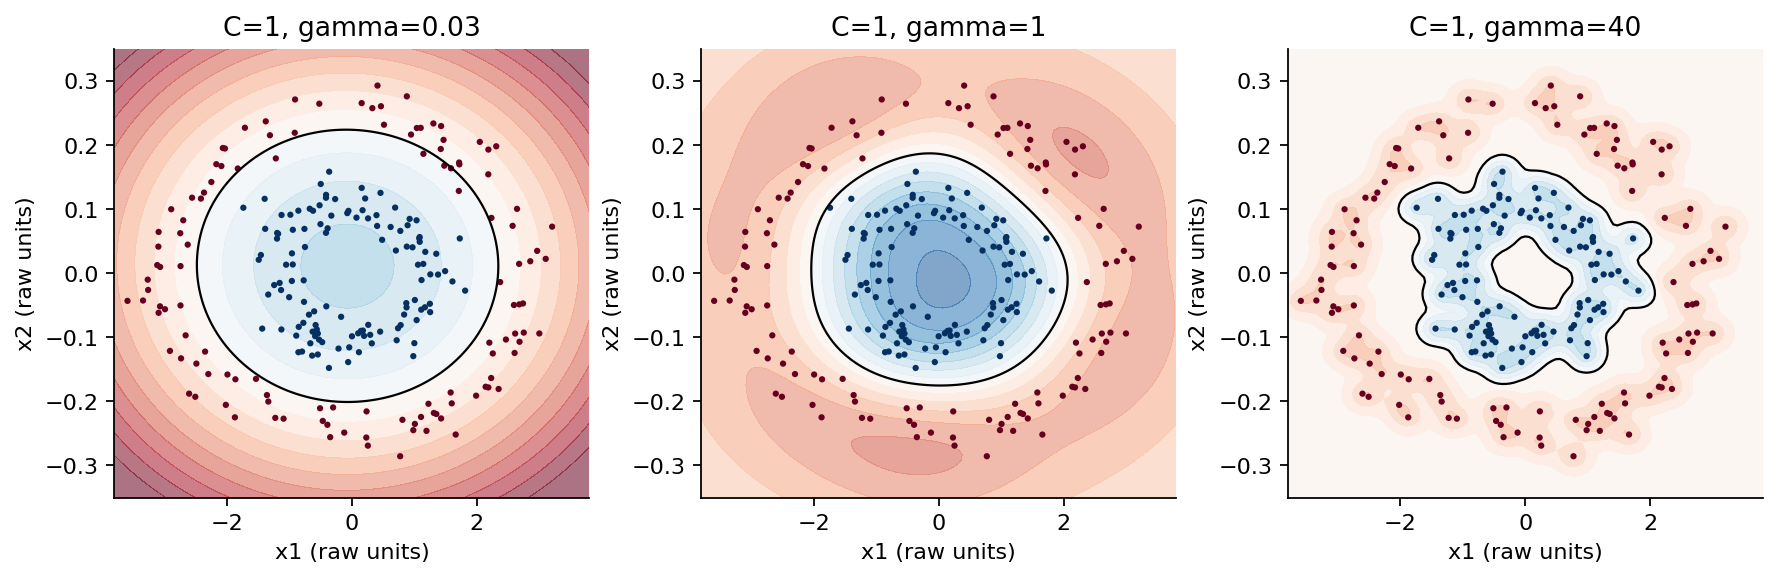

In [9]:
display(Image(filename=str(figure_paths[1])))

### 图 3 03_equal_budget
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

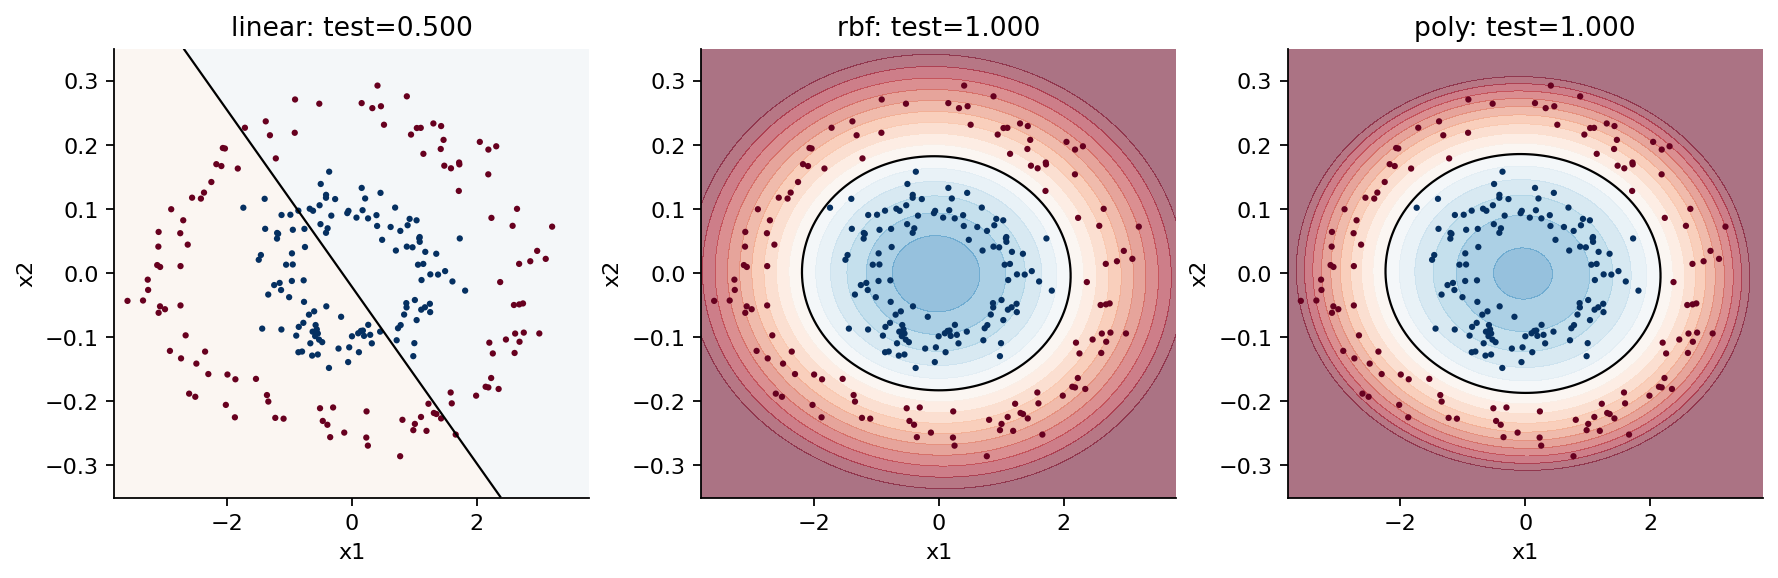

In [10]:
display(Image(filename=str(figure_paths[2])))

### 图 4 04_resources
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

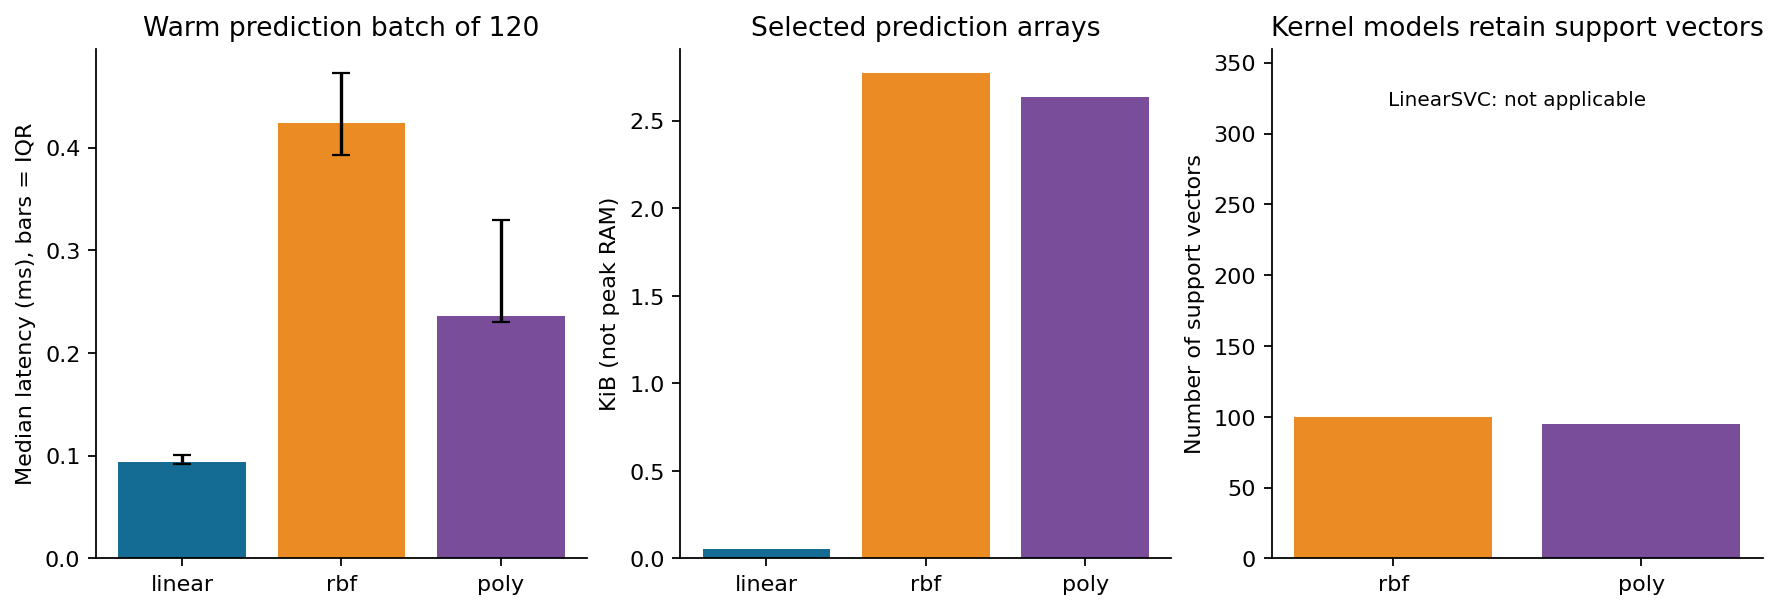

In [11]:
display(Image(filename=str(figure_paths[3])))

### 图 5 05_storage
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

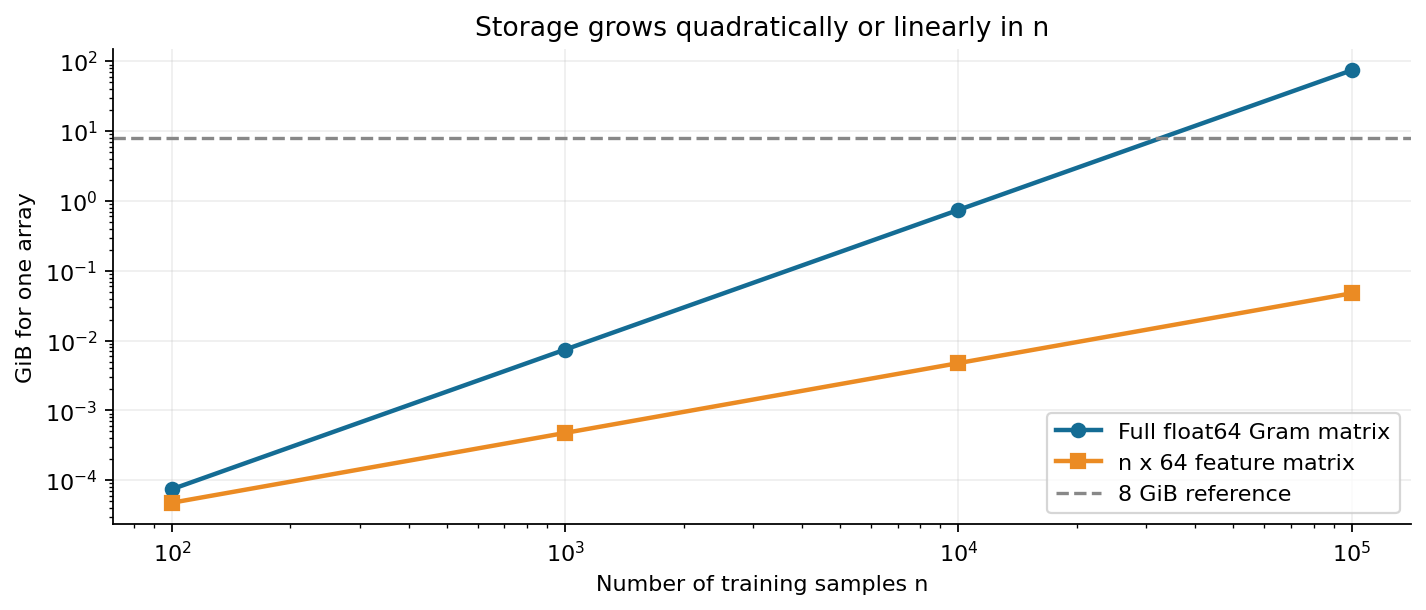

In [12]:
display(Image(filename=str(figure_paths[4])))

### 图 6 06_approximation
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

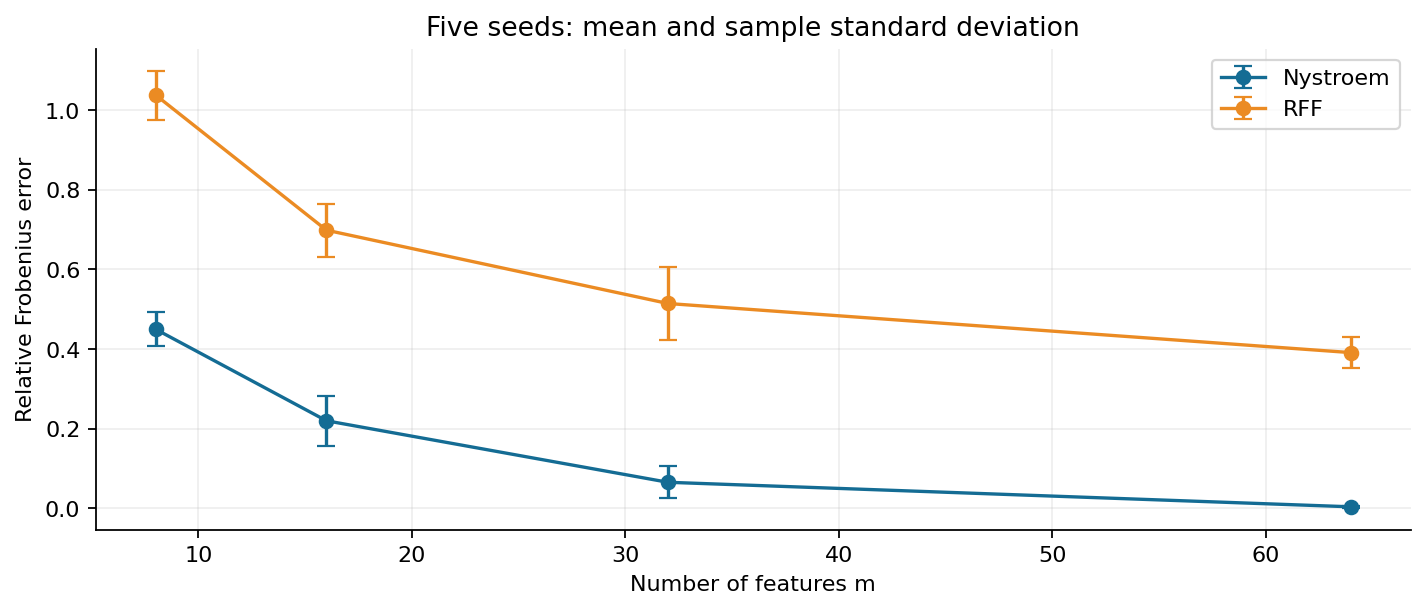

In [13]:
display(Image(filename=str(figure_paths[5])))

## 完成后的判断
1. 写出一个从数值证据支持的结论。
2. 写出一个当前实验尚未支持的外推。
3. 说明若要扩大数据规模，你会先测量哪种资源。

修改参数或数据时使用新的实验目录与预先规定的评估协议，不要覆盖冻结参考结果后仍沿用原验收结论。